In [2]:
# import packages
import numpy as np
import os
import csv
import scipy as scipy
from scipy.optimize import leastsq
import lmfit
import matplotlib.pyplot as plt
%matplotlib inline

### Define fitting functions ###

In [2]:
""" Lorentzian fitting to locate peaks in Stark scans """

# defines the functional form of the Lorentzian
def lorentz(x, x0, A, gamma):
    return A*gamma**2/(gamma**2 + (x - x0)**2)

# defines a multi-Lorentzian
def multi_lorentz(x,params):
    offset = params[0]
    paramsRest = params[1:]
    assert not (len(paramsRest) % 3)  # checks that the size of paramsRest is a multiple of 3
    # generates sum of Lorentzians
    Sum = sum([lorentz(x, *paramsRest[i:i+3]) for i in range(0, len(paramsRest), 3)]) 
    return offset + Sum

# calculates residuals of the multi-Lorentzian fit
def res_multi_lorentz(params, xData, yData):
    diff = [multi_lorentz(x, params) - y for x,y in zip(xData,yData)]
    return diff

# look for peaks in Stark scans
def lorentz_peak_finder(x_data, y_data, num_peaks, return_params = False):
    # normalize the data being fitted (helps avoid false peaks)
    max_y = max(y_data)
    y_data = y_data/max_y

    gamma_test = 8  # make a guess for gamma
    yDataLoc = y_data
    startValues = [max(y_data)]  # create a list to store guess values, starting with overall offset
    counter = 0

    x_peaks = []  # save the positions of peaks

    # start searching for peaks
    while max(yDataLoc) - min(yDataLoc) > 0.1:
        counter += 1
        ### search for fixed number of peaks...emergency break to avoid infinite loop
        if counter > num_peaks:
            break
        maxP = np.argmax(yDataLoc)  # find index of maximum value
        maxY = y_data[maxP]   # find corresponding y-value
        x0 = x_data[maxP]     # find corresponding x-value
        x_peaks.append(x0)
        startValues += [x0, maxY - min(yDataLoc), gamma_test] # add new test values for fitting
        # perform least squares fitting (parameters are refined after each loop iteration)
        popt, ier = leastsq(res_multi_lorentz, startValues, args = (x_data,y_data))
        # resets the y data by "eliminating" the current tallest peak to prepare for next iteration
        yDataLoc = [y - multi_lorentz(x, popt) for x,y in zip(x_data,y_data)]

    get_peaks = np.array([popt[i] for i in range(2,len(popt),3)],float)*max_y # rescale the peaks
    x_peaks = np.array(x_peaks,float)

    # you can optionally return all fitting parameters or just the ones needed for quadratic fitting
    if return_params:
        for i in range(2,len(popt),3):
            popt[i] *= max_y
        return x_peaks, get_peaks, popt
    else:
        return x_peaks, get_peaks

""" Quadratic fitting of Stark lines to extract compensation voltages """

# defines the functional form of quadratic
def quadratic(x, a, b, c):
    return a*x**2 + b*x + c

# calculates residuals of the quadratic fit
def res_quadratic(params, xData, yData):
    diff = [quadratic(x, *params) - y for x,y in zip(xData,yData)]
    return diff

# perform least squares quadratic fitting on Stark peaks
def quad_fit(xData, yData):
    startValues = [1,1,1]  # make some random guess of fitting parameters
    popt, ier = leastsq(res_quadratic, startValues, args = (xData, yData)) # least squares fitting
    return popt[0],popt[1],popt[2]

# calculate line centers
def quad_center(a,b):
    x0 = -b/(2*a)
    return x0

### Testing with example data ###

In [3]:
# create some sample data with multiple Lorentzians
x_data = np.linspace(1,300,250)

# overall offset
offset = 100

# Lorentzian parameters
x1, a1, g1 = 100, 50, 5
x2, a2, g2 = 150, 100, 10
x3, a3, g3 = 200, 50, 5

# generate y_data
y_data = lorentz(x_data, x1, a1, g1) + lorentz(x_data, x2, a2, g2) + lorentz(x_data, x3, a3, g3)
y_noise = np.random.ranf(250)*5  # add some noise to the y_data
y_data += y_noise

# store parameters in array
params = np.array([offset, x1, a1, g1, x2, a2, g2, x3, a3, g3])

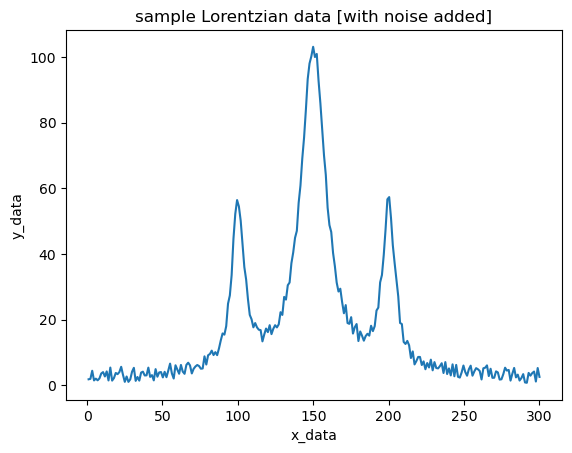

In [4]:
# plot sample data
plt.figure(1)
plt.plot(x_data, y_data)
plt.xlabel('x_data')
plt.ylabel('y_data')
plt.title('sample Lorentzian data [with noise added]')
plt.show()

In [1]:
# perform Lorentzian fitting to find peaks (also give full fitting parameters)
x_peaks, get_peaks, popt = lorentz_peak_finder(x_data, y_data, num_peaks = 3, return_params = True)
print('peak locations: \n', x_peaks)
print('peak values: \n', get_peaks)
print('fitting parameters: \n', popt)

NameError: name 'lorentz_peak_finder' is not defined

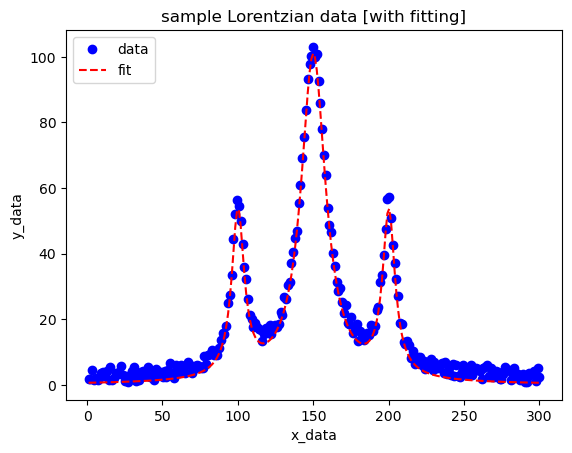

In [6]:
# plot sample data with multi-Lorentzian fit
y_data_fit = [multi_lorentz(x, popt) for x in x_data]

plt.figure(2)
plt.plot(x_data, y_data, 'bo', label = 'data')
plt.plot(x_data, y_data_fit, 'r--', label = 'fit')
plt.xlabel('x_data')
plt.ylabel('y_data')
plt.title('sample Lorentzian data [with fitting]')
plt.legend(loc = 'upper left')
plt.show()

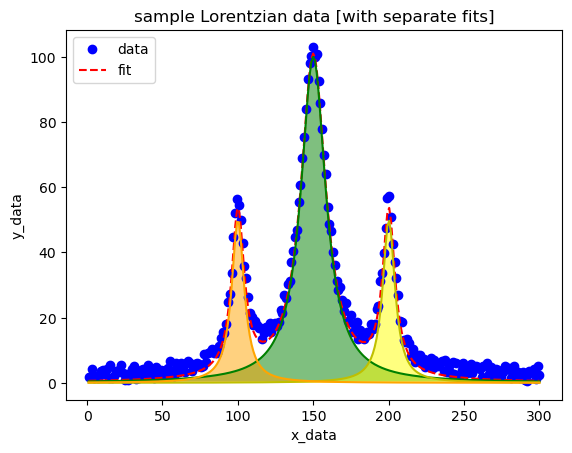

In [7]:
lorentz_1 = lorentz(x_data, *popt[1:4])
lorentz_2 = lorentz(x_data, *popt[4:7])
lorentz_3 = lorentz(x_data, *popt[7:])

# plot the individual fits as well
plt.figure(3)
plt.plot(x_data, y_data, 'bo', label = 'data')
plt.plot(x_data, y_data_fit, 'r--', label = 'fit')

# peak 1
plt.plot(x_data, lorentz_1, "g")
plt.fill_between(x_data, lorentz_1.min(), lorentz_1, facecolor = "green", alpha = 0.5)
  
# peak 2
plt.plot(x_data, lorentz_2, "y")
plt.fill_between(x_data, lorentz_2.min(), lorentz_2, facecolor = "yellow", alpha = 0.5)

# peak 3
plt.plot(x_data, lorentz_3, "orange")
plt.fill_between(x_data, lorentz_3.min(), lorentz_3, facecolor = "orange", alpha = 0.5)

plt.xlabel('x_data')
plt.ylabel('y_data')
plt.title('sample Lorentzian data [with separate fits]')
plt.legend(loc = 'upper left')
plt.show()

In [8]:
# get quadratic fitting parameters
a,b,c = quad_fit(x_peaks, get_peaks)
print('fitting parameters: ', a,b,c)

# calculate the line center
x0 = quad_center(a,b)
print('line center: ', x0)

fitting parameters:  -0.019686270868750185 5.900467191216408 -342.1320893925633
line center:  149.86249123958663


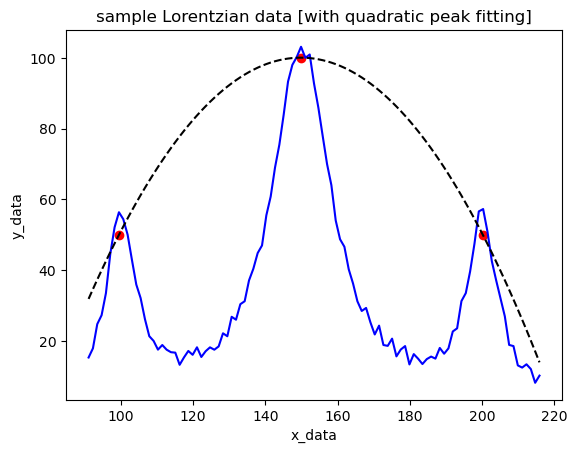

In [9]:
# plot results

# only select region over which peaks are present in original data 
imin, imax = 75, 180

y_data_quad = quadratic(x_data[imin:imax], a, b, c)

plt.figure(4)
plt.plot(x_data[imin:imax], y_data[imin:imax],'b')
plt.plot(x_data[imin:imax], y_data_quad,'k--')
plt.scatter(x_peaks,get_peaks, color = 'r')
plt.xlabel('x_data')
plt.ylabel('y_data')
plt.title('sample Lorentzian data [with quadratic peak fitting]')
plt.show()

### Testing the code with real data ###

In [10]:
"""Removes the first N lines from a file using a temporary file."""
# n = 9 for 1-d csv files, n = 11 for 2-d csv files
def strip_nlines(filename, n):

    temp_filename = filename + ".temp"

    with open(filename, 'r') as infile, open(temp_filename, 'w') as outfile:
        # Skip the first N lines
        for _ in range(n):
            infile.readline()

        # Write the remaining lines to the temporary file
        for line in infile:
            outfile.write(line)

    # Replace the original file with the temporary file
    os.replace(temp_filename, filename)

"""Imports a CSV file into a list of lists. Each inner list represents a row from the CSV."""
# function to convert csv file into a numpy array
def csv_to_array(filename):
    data = []
    
    with open(filename, 'r', newline = '') as csvfile:
        reader = csv.reader(csvfile)
        for row in reader:
            data.append(row)
            
    return np.array(data, float)

In [11]:
# remove first 11 lines from Stark data, convert to array

strip_nlines("20251130_ID14.csv", n = 11)

# yields an array of shape (N_volt x N_step) by 3 -- in this case 4400 x 3
stark_map = csv_to_array("20251130_ID14.csv") 
#print(stark_map)
print(stark_map.shape)

FileNotFoundError: [Errno 2] No such file or directory: '20251130_ID14.csv'

In [ ]:
stride = 1    # stepper motor step size
freq_factor = 129 # [kHz]; frequency changer per motor step
half_width = 200  # half the total stepper motor scan range
freqs = np.arange(2*half_width)*stride*freq_factor # [kHz]; equivalent laser detuning

"""reformat the Stark data for easier analysis"""

# start by picking out the indices where each frequency scan begins at a fixed voltage
indices = np.arange(0,stark_map.shape[0],2*half_width)
num_voltage = len(indices)

# create an empty array to store average counts versus stepper motor position and electrode voltage
Stark_map = np.empty([2*half_width, num_voltage],float)

# populate empty array with counts, with each column at a certain voltage
j = 0
for r in indices:
    Stark_map[:,j] = stark_map[r:r+400,2].T
    j += 1

In [ ]:
Stark_map.shape

(400, 11)

In [ ]:
from lmfit.models import LorentzianModel

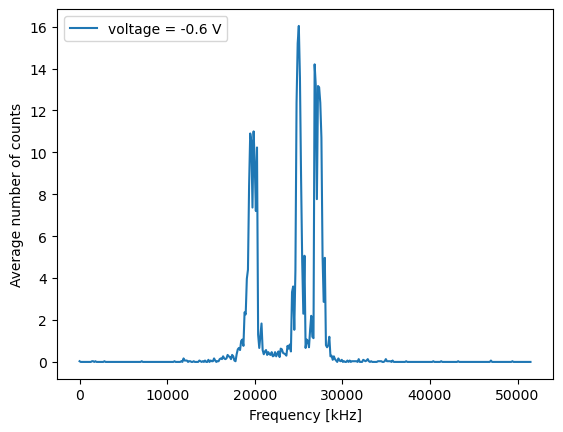

In [ ]:
# plot data from frequency scan i
i = 2
voltages = np.linspace(-1,1,11)

plt.figure()
plt.plot(freqs, Stark_map[:,i].T, label = 'voltage = {} V'.format(voltages[i]))
plt.xlabel('Frequency [kHz]')
plt.ylabel('Average number of counts')
plt.legend(loc = 'upper left')
plt.show()

In [ ]:
# create a composite model
model = LorentzianModel(prefix = 'p1_') + LorentzianModel(prefix = 'p2_') + LorentzianModel(prefix = 'p3_')

# set initial parameters (adjust based on your data)
delta = 0.01
params = model.make_params()
params['p1_center'].set(value = 30000)
params['p1_amplitude'].set(value = 14)
params['p1_sigma'].set(value = 500)

params['p2_center'].set(value = 25000)
params['p2_amplitude'].set(value = 16)
params['p2_sigma'].set(value = 500)

params['p3_center'].set(value = 20000)
params['p3_amplitude'].set(value = 12)
params['p3_sigma'].set(value = 500)

# perform the fit
result = model.fit(Stark_map[:,i].T, params, x = freqs)

# print the fitting report
print(result.fit_report())

[[Model]]
    ((Model(lorentzian, prefix='p1_') + Model(lorentzian, prefix='p2_')) + Model(lorentzian, prefix='p3_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 855
    # data points      = 400
    # variables        = 9
    chi-square         = 253.673069
    reduced chi-square = 0.64878023
    Akaike info crit   = -164.167296
    Bayesian info crit = -128.244115
    R-squared          = 0.90450619
[[Variables]]
    p1_amplitude:  13162.8557 +/- 528.005300 (4.01%) (init = 14)
    p1_center:     24992.9927 +/- 9.48933941 (0.04%) (init = 30000)
    p1_sigma:      245.526588 +/- 13.7397641 (5.60%) (init = 500)
    p2_amplitude:  16088.1413 +/- 699.845685 (4.35%) (init = 16)
    p2_center:     19730.7164 +/- 20.0849584 (0.10%) (init = 25000)
    p2_sigma:      463.020689 +/- 28.4713545 (6.15%) (init = 500)
    p3_amplitude:  17175.5698 +/- 667.144072 (3.88%) (init = 12)
    p3_center:     27268.7157 +/- 14.8304688 (0.05%) (init = 20000)
    p3_sigma:     

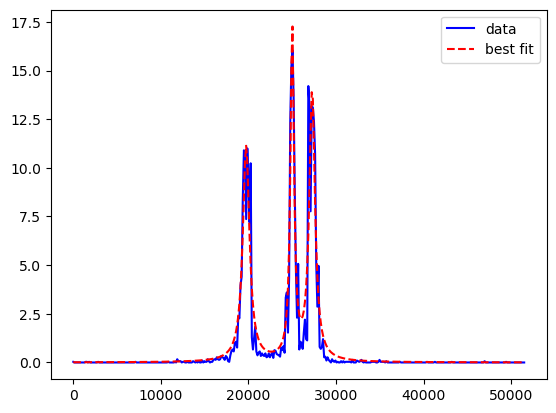

In [ ]:
# plot results
plt.figure()
plt.plot(freqs, Stark_map[:,i].T, 'b', label = 'data')
plt.plot(freqs, result.best_fit, 'r--', label = 'best fit')
#plt.plot(freqs, result.eval_components(x = freqs)['p1_'], '--', label = 'p1_')
#plt.plot(freqs, result.eval_components(x = freqs)['p2_'], '--', label = 'p2_')
#plt.plot(freqs, result.eval_components(x = freqs)['p3_'], '--', label = 'p3_')
plt.legend()
plt.show()

### Try to use lmfit package instead ###

In [ ]:
# documentation: https://lmfit.github.io/lmfit-py/index.html